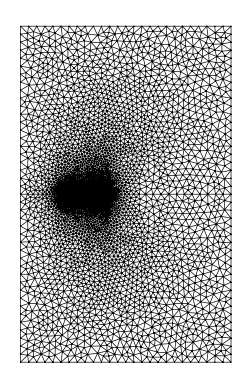

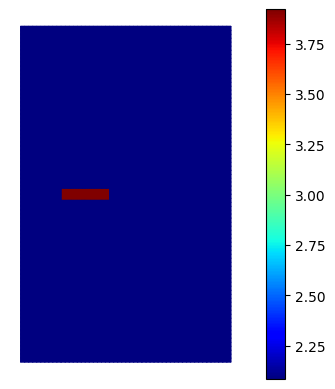

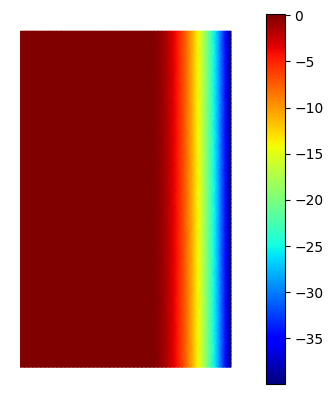

  0%|          | 0/20 [00:00<?, ?it/s]

In [ ]:
# ---
# jupyter:
#   jupytext:
#     formats: py:percent,md:myst
#     text_representation:
#       extension: .py
#       format_name: percent
#       format_version: '1.3'
#       jupytext_version: 1.15.0
#   kernelspec:
#     display_name: Python 3
#     name: python3
# ---

# %% [markdown]
# # Bent waveguide losses — buried channel SiN waveguide
# This example uses an effective epsilon approximation for the bend, for more precise implementation see julia example.
#
# Geometry change from the rib/ridge version: the core is fully embedded (buried) in
# oxide cladding, with no exposed top surface and no separate slab layer.

# %% tags=["hide-input"]
from collections import OrderedDict

import matplotlib.pyplot as plt
import numpy as np
from shapely import box
from shapely.ops import clip_by_rect
from skfem import Basis, ElementDG, ElementTriP1
from skfem.io.meshio import from_meshio
from tqdm import tqdm

from femwell.maxwell.waveguide import compute_modes
from femwell.mesh import mesh_from_OrderedDict

# %% [markdown]
# We describe the geometry using shapely.
# The core is a box fully surrounded by oxide cladding (buried channel), so there's
# no slab layer — just core + a single cladding region split into "box" (below) and
# "clad" (above) purely for bookkeeping (both are the same material, oxide).

# %%
wavelength = 1.55

wg_width = 1.2
wg_thickness = 0.3
core_y0 = 4.0  # depth of core center region within the oxide stack (µm), fully buried
pml_distance = wg_width / 2 + 1.0  # distance from center
pml_thickness = 2

core = box(-wg_width / 2, core_y0, wg_width / 2, core_y0 + wg_thickness)
env = box(-1 - wg_width / 2, 0, pml_distance + pml_thickness, core_y0 + wg_thickness + 4)

core_mid = core_y0 + wg_thickness / 2

polygons = OrderedDict(
    core=core,
    box=clip_by_rect(env, -np.inf, -np.inf, np.inf, core_mid),
    clad=clip_by_rect(env, -np.inf, core_mid, np.inf, np.inf),
)

resolutions = dict(
    core={"resolution": 0.03, "distance": 1},
)

mesh = from_meshio(
    mesh_from_OrderedDict(polygons, resolutions, default_resolution_max=0.2, filename="mesh.msh")
)
mesh.draw().show()

# %% [markdown]
# On this mesh, we define the epsilon. We do this by setting domainwise the epsilon to
# the squared refractive index. Core is Si3N4 (~1.98 at 1550nm, LPCVD stoichiometric —
# adjust to your process's measured value), cladding is fused silica (~1.444).
# We additionally add a PML layer by adding an imaginary part to the epsilon.

# %%
basis0 = Basis(mesh, ElementDG(ElementTriP1()))
epsilon = basis0.zeros(dtype=complex)
for subdomain, n in {"core": 1.98, "box": 1.444, "clad": 1.444}.items():
    epsilon[basis0.get_dofs(elements=subdomain)] = n**2
epsilon += basis0.project(
    lambda x: -10j * np.maximum(0, x[0] - pml_distance) ** 2,
    dtype=complex,
)
basis0.plot(epsilon.real, shading="gouraud", colorbar=True).show()
basis0.plot(epsilon.imag, shading="gouraud", colorbar=True).show()

# %% [markdown]
# We calculate now the modes for the geometry we just set up.
# We do it first for the case, where the bend-radius is infinite, i.e. a straight waveguide.
# This is done to have a reference effective refractive index for starting
# and for mode overlap calculations between straight and bent waveguides.

# %%
modes_straight = compute_modes(
    basis0, epsilon, wavelength=wavelength, num_modes=1, order=2, radius=np.inf
)

# %% [markdown]
# Now we calculate the modes of bent waveguides with different radii.
# Subsequently, we calculate the overlap integrals between the modes to determine the coupling efficiency
# And determine from the imaginary part the bend loss.

# %% tags=["remove-stderr"]
radiuss = np.linspace(300, 80, 20)
radiuss_lams = []
overlaps = []
lam_guess = modes_straight[0].n_eff
for radius in tqdm(radiuss):
    modes = compute_modes(
        basis0,
        epsilon,
        wavelength=wavelength,
        num_modes=1,
        order=2,
        radius=radius,
        n_guess=lam_guess,
        solver="scipy",
    )
    lam_guess = modes[0].n_eff
    radiuss_lams.append(modes[0].n_eff)

    overlaps.append(modes_straight[0].calculate_overlap(modes[0]))

# %% [markdown]
# And now we plot it!

# %% tags=["hide-input"]
plt.xlabel("Radius / μm")
plt.ylabel("Mode overlap loss with straight waveguide mode / dB")
plt.yscale("log")
plt.plot(radiuss, -10 * np.log10(np.abs(overlaps) ** 2))
plt.show()
plt.xlabel("Radius / μm")
plt.ylabel("90-degree bend transmission / dB")
plt.yscale("log")
plt.plot(
    radiuss,
    -10
    * np.log10(
        np.exp(-2 * np.pi / wavelength * radius * np.abs(np.imag(radiuss_lams)) * np.pi / 2)
    ),
)
plt.show()

# %% [markdown]
# We now plot the mode calculated for the smallest bend radius to check that it's still within the waveguide.
# As modes can have complex fields as soon as the epsilon gets complex, so we get a complex field for each mode.
# Here we show only the real part of the mode.

# %% tags=["hide-input"]
for mode in modes:
    print(f"Effective refractive index: {mode.n_eff:.14f}")
    mode.plot(mode.E.real, colorbar=True, direction="x")
    plt.show()